# Tau Decay Exploration for jGCaMP7s

Exploring how different tau values affect Suite2p spike inference for jGCaMP7s.

**jGCaMP7s decay constant:** ~1.0s (Dana et al. 2019 Nature Methods)

Testing tau values: 0.8, 1.0, 1.3 (default), 1.5 seconds

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

# Add utilities to path
sys.path.insert(0, str(Path.cwd().parent.parent / 'mbo_utilities'))
sys.path.insert(0, str(Path.cwd().parent.parent))

from suite2p.extraction import dcnv

plt.style.use('dark_background')
%matplotlib inline

## Load existing Suite2p results

In [2]:
# Load from merged consolidated results
suite2p_path = Path(r"\\rbo-s1\S1_DATA\lbm\kbarber\2025-11-04-mk311\suite2p")
merged_path = suite2p_path / "merged"

ops = np.load(merged_path / "ops.npy", allow_pickle=True).item()
F = np.load(merged_path / "F.npy")
Fneu = np.load(merged_path / "Fneu.npy")
spks_original = np.load(merged_path / "spks.npy")
iscell = np.load(merged_path / "iscell.npy")

# Get accepted cells only
accepted = iscell[:, 0] == 1
F = F[accepted]
Fneu = Fneu[accepted]
spks_original = spks_original[accepted]

fs = ops.get('fs', 30.0)
neucoeff = ops.get('neucoeff', 0.7)
baseline_method = ops.get('baseline', 'maximin')
win_baseline = ops.get('win_baseline', 60.0)
sig_baseline = ops.get('sig_baseline', 10.0)
tau_original = ops.get('tau', 1.3)

print(f"Loaded {F.shape[0]} cells, {F.shape[1]} frames")
print(f"Frame rate: {fs:.2f} Hz")
print(f"Original tau: {tau_original}s")

Loaded 6507 cells, 58825 frames
Frame rate: 17.07 Hz
Original tau: 1.3s


## Compute neuropil-corrected traces

Suite2p deconvolution operates on F - neucoeff * Fneu

In [3]:
F_corrected = F - neucoeff * Fneu
print(f"Neuropil correction: F - {neucoeff} * Fneu")

Neuropil correction: F - 0.7 * Fneu


## Run deconvolution with different tau values

Suite2p's dcnv.oasis uses tau to model calcium decay kinetics when inferring spikes

In [6]:
tau_values = [0.8, 1.0, 1.3, 1.5]

# Storage for results
spks_dict = {}

# Run deconvolution for each tau
for tau in tau_values:
    print(f"\nRunning deconvolution with tau={tau}s...")

    spks = dcnv.oasis(
        F=F_corrected,
        batch_size=ops.get('batch_size', 500),
        tau=tau,
        fs=fs,
    )

    spks_dict[tau] = spks

    # Quick stats
    n_spikes = np.sum(spks > 0)
    spikes_per_cell = n_spikes / F.shape[0]
    print(f"  Total spikes: {n_spikes:,}")
    print(f"  Spikes/cell: {spikes_per_cell:.1f}")
    print(f"  Mean spike amplitude: {np.mean(spks[spks > 0]):.3f}")

print("\nDeconvolution complete for all tau values")


Running deconvolution with tau=0.8s...
  Total spikes: 128,015,700
  Spikes/cell: 19673.5
  Mean spike amplitude: 59.482

Running deconvolution with tau=1.0s...
  Total spikes: 112,827,434
  Spikes/cell: 17339.4
  Mean spike amplitude: 54.342

Running deconvolution with tau=1.3s...
  Total spikes: 96,733,463
  Spikes/cell: 14866.1
  Mean spike amplitude: 49.041

Running deconvolution with tau=1.5s...
  Total spikes: 88,734,103
  Spikes/cell: 13636.7
  Mean spike amplitude: 46.452

Deconvolution complete for all tau values


## Compare spike inference across tau values

Smaller tau = faster decay = more sensitive to transients, more spikes
Larger tau = slower decay = less sensitive, fewer spikes

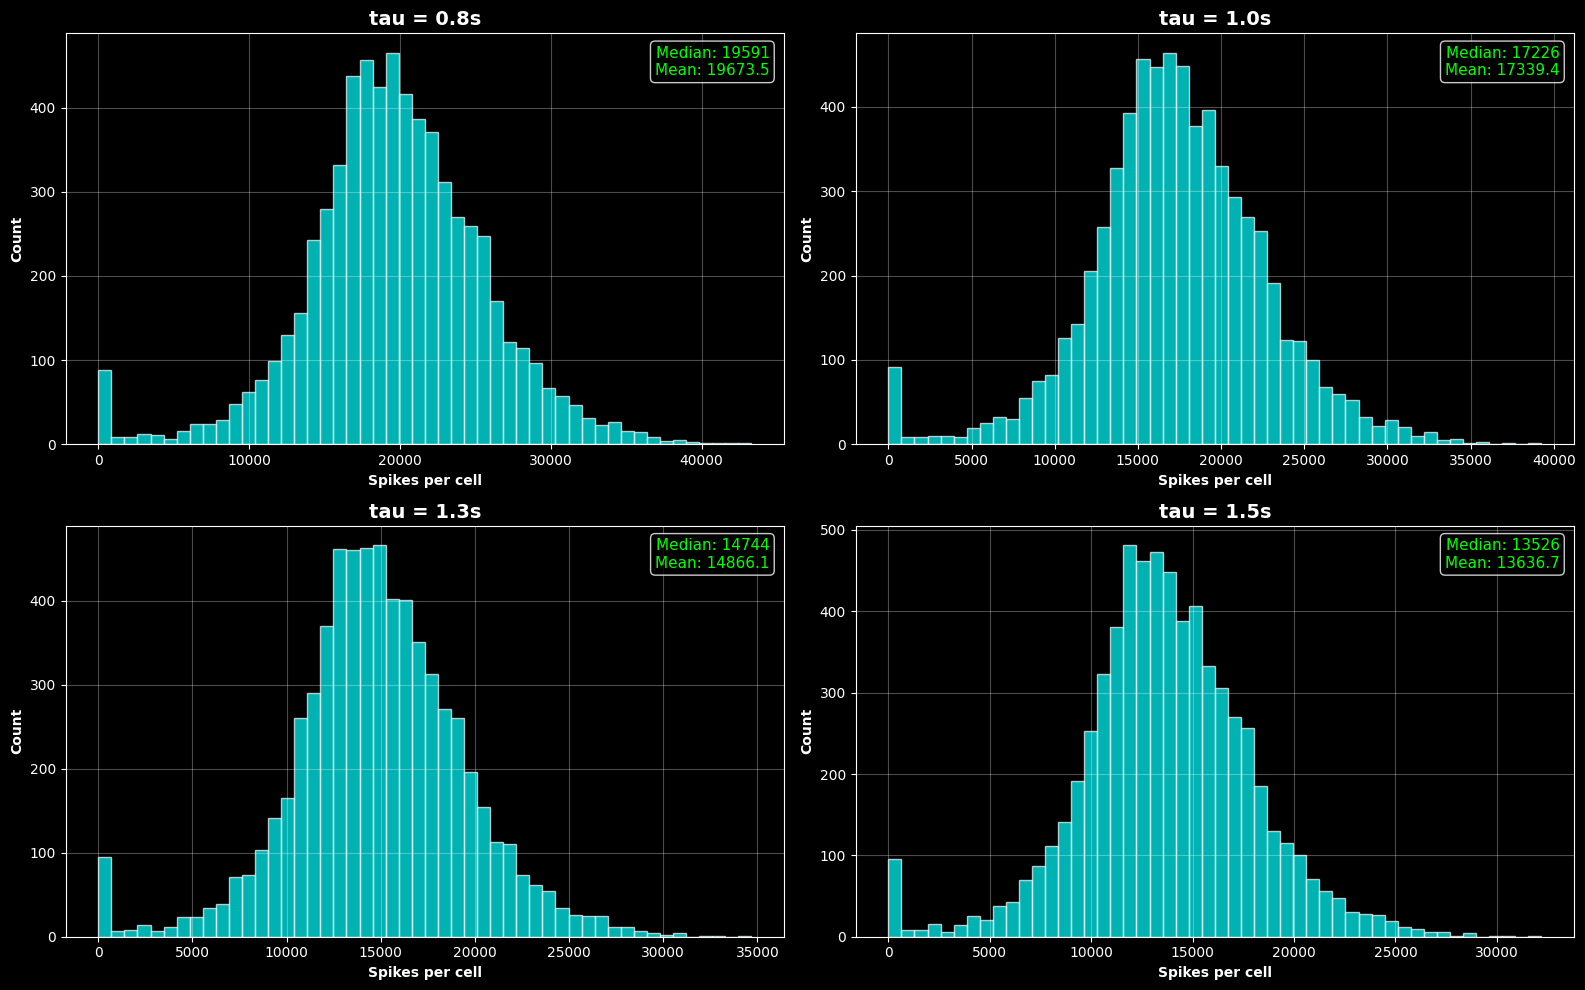

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor='black')
axes = axes.flatten()

for ax, tau in zip(axes, tau_values):
    spks = spks_dict[tau]

    # Total spikes per cell
    spikes_per_cell = np.sum(spks > 0, axis=1)

    ax.hist(spikes_per_cell, bins=50, color='cyan', alpha=0.7, edgecolor='white')
    ax.set_xlabel('Spikes per cell', fontweight='bold')
    ax.set_ylabel('Count', fontweight='bold')
    ax.set_title(f'tau = {tau}s', fontweight='bold', fontsize=14)
    ax.grid(alpha=0.3)

    # Stats text
    median_spks = np.median(spikes_per_cell)
    mean_spks = np.mean(spikes_per_cell)
    ax.text(0.98, 0.97,
            f'Median: {median_spks:.0f}\nMean: {mean_spks:.1f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=11, color='lime',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))

plt.tight_layout()
plt.savefig(merged_path / 'tau_comparison_spikes_per_cell.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()

## Example traces showing tau effect

Pick a highly active cell and visualize how different tau values affect spike inference

Plotting cell 4596 (highest F variance)


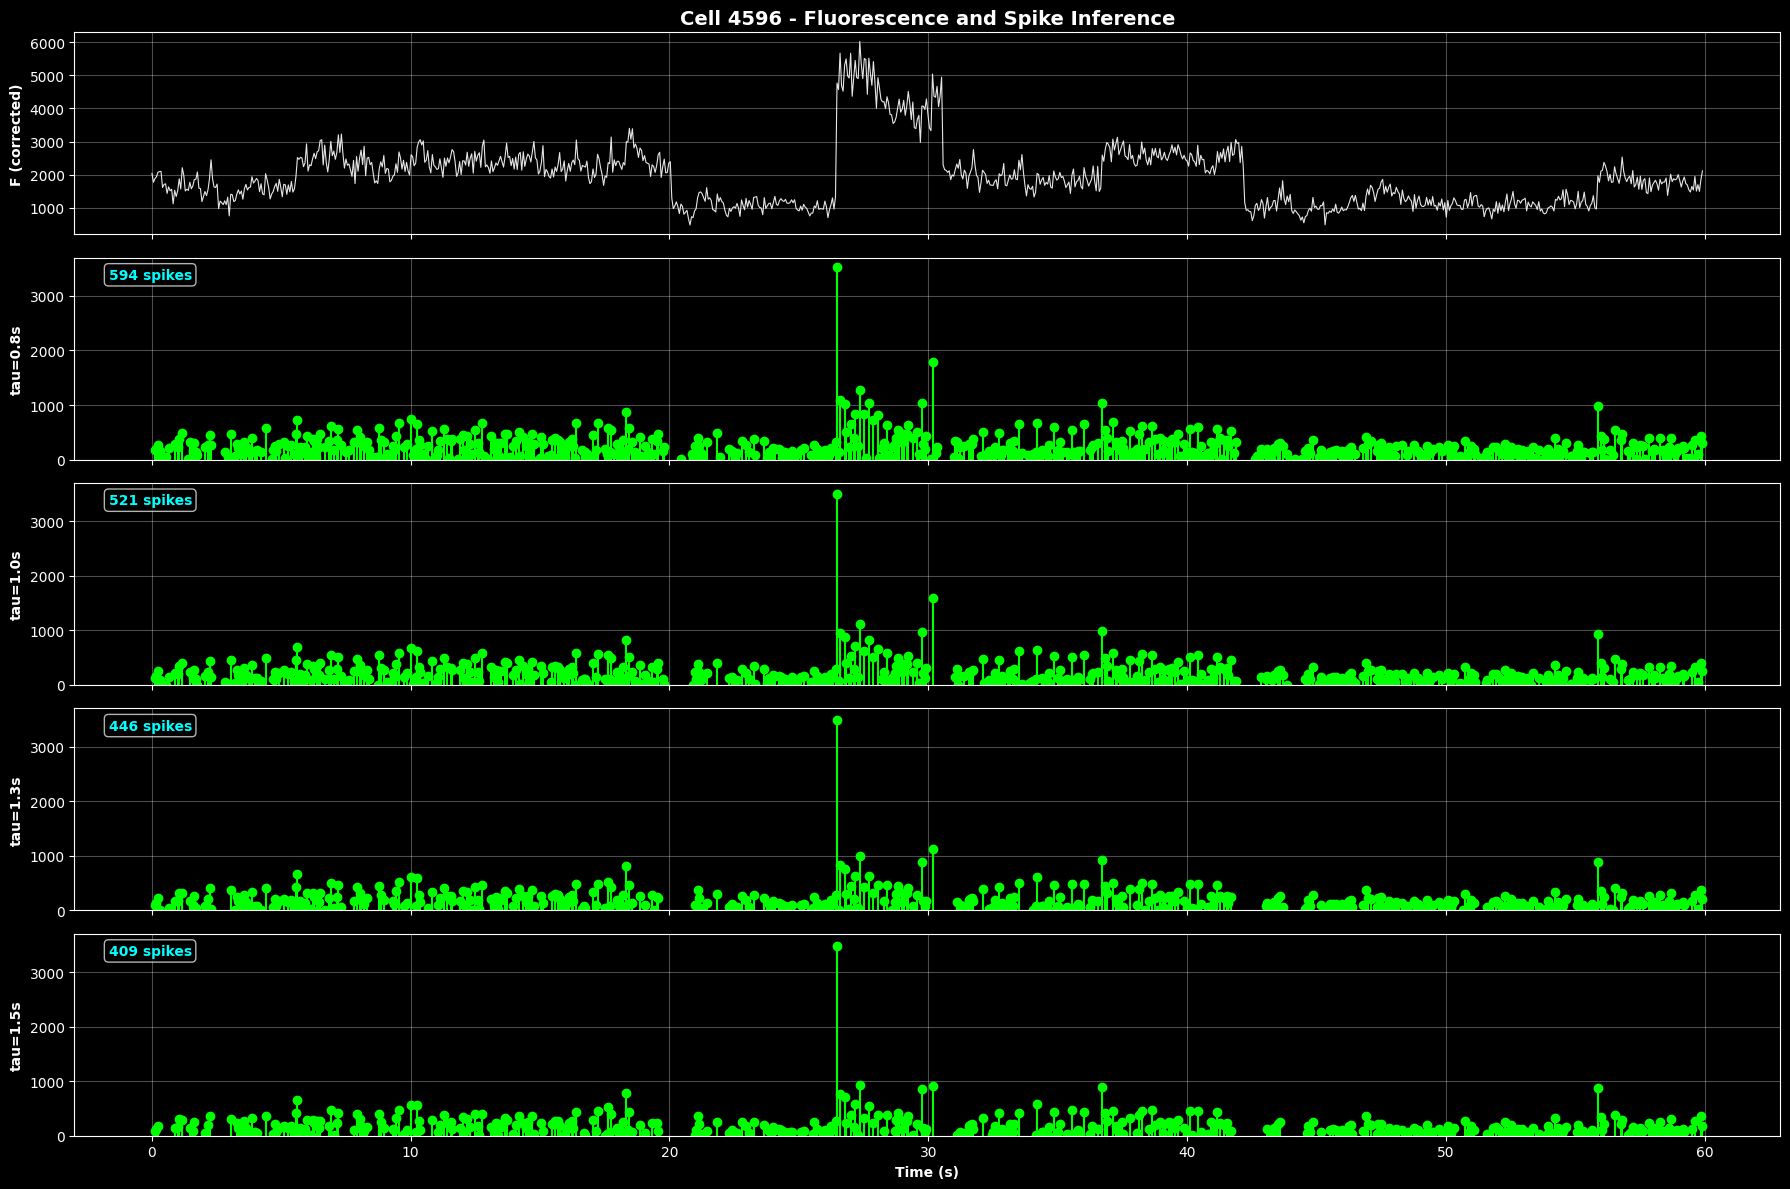

In [10]:
# Find most active cell based on std of fluorescence (not spikes to avoid bias)
F_activity = np.std(F_corrected, axis=1)
most_active_idx = np.argmax(F_activity)

print(f"Plotting cell {most_active_idx} (highest F variance)")

# Time window to plot (first 60 seconds)
time_window = 60  # seconds
n_frames = int(time_window * fs)
time = np.arange(n_frames) / fs

# Get traces for this cell
F_cell = F_corrected[most_active_idx, :n_frames]

# Find global max spike amplitude across all tau values for consistent y-axis
max_spike_amp = 0
for tau in tau_values:
    spks_window = spks_dict[tau][most_active_idx, :n_frames]
    max_spike_amp = max(max_spike_amp, spks_window.max())

# Plot
fig, axes = plt.subplots(len(tau_values) + 1, 1, figsize=(18, 12),
                         facecolor='black', sharex=True)

# Raw fluorescence on top
axes[0].plot(time, F_cell, linewidth=0.8, color='white', alpha=0.9)
axes[0].set_ylabel('F (corrected)', fontweight='bold')
axes[0].set_title(f'Cell {most_active_idx} - Fluorescence and Spike Inference',
                  fontweight='bold', fontsize=14)
axes[0].grid(alpha=0.3)

# Spike inference for each tau with shared y-axis
for i, tau in enumerate(tau_values, start=1):
    spks = spks_dict[tau][most_active_idx, :n_frames]

    # Plot as stem (removed deprecated use_line_collection)
    spike_times = time[spks > 0]
    spike_amps = spks[spks > 0]

    axes[i].stem(spike_times, spike_amps, linefmt='lime', markerfmt='o', basefmt=' ')
    axes[i].set_ylabel(f'tau={tau}s', fontweight='bold')
    axes[i].set_ylim(0, max_spike_amp * 1.05)  # Consistent scale
    axes[i].grid(alpha=0.3)

    # Count spikes in window
    n_spikes_window = np.sum(spks > 0)
    axes[i].text(0.02, 0.95, f'{n_spikes_window} spikes',
                transform=axes[i].transAxes, va='top', fontsize=10,
                color='cyan', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

axes[-1].set_xlabel('Time (s)', fontweight='bold')
plt.tight_layout()
plt.savefig(merged_path / 'tau_comparison_example_traces.png', dpi=150,
            bbox_inches='tight', facecolor='black')
plt.show()

## Quantitative comparison table

Summary statistics for all tau values

In [12]:
print("\n" + "="*80)
print("TAU COMPARISON SUMMARY (jGCaMP7s)")
print("="*80)
print(f"{'Tau (s)':<12} {'Total Spikes':<15} {'Spikes/Cell':<15} {'Mean Amp':<12} {'Median Amp':<12}")
print("-"*80)

for tau in tau_values:
    spks = spks_dict[tau]
    total_spikes = np.sum(spks > 0)
    spikes_per_cell = total_spikes / F.shape[0]

    spike_amps = spks[spks > 0]
    mean_amp = np.mean(spike_amps)
    median_amp = np.median(spike_amps)

    marker = "  <-- jGCaMP7s" if tau == 1.0 else ""
    marker = "  <-- Suite2p default" if tau == 1.3 else marker

    print(f"{tau:<12.1f} {total_spikes:<15,} {spikes_per_cell:<15.1f} {mean_amp:<12.4f} {median_amp:<12.4f}{marker}")

print("="*80)
print("\nRecommendation: Use tau=1.0s for jGCaMP7s (Dana et al. 2019)")
print("Default Suite2p tau=1.3s was optimized for GCaMP6s/GCaMP6f")


TAU COMPARISON SUMMARY (jGCaMP7s)
Tau (s)      Total Spikes    Spikes/Cell     Mean Amp     Median Amp  
--------------------------------------------------------------------------------
0.8          128,015,700     19673.5         59.4820      40.2223     
1.0          112,827,434     17339.4         54.3422      36.4447       <-- jGCaMP7s
1.3          96,733,463      14866.1         49.0414      32.5612       <-- Suite2p default
1.5          88,734,103      13636.7         46.4519      30.6623     

Recommendation: Use tau=1.0s for jGCaMP7s (Dana et al. 2019)
Default Suite2p tau=1.3s was optimized for GCaMP6s/GCaMP6f


## Pairwise spike correlation

How similar are the spike trains between different tau values?

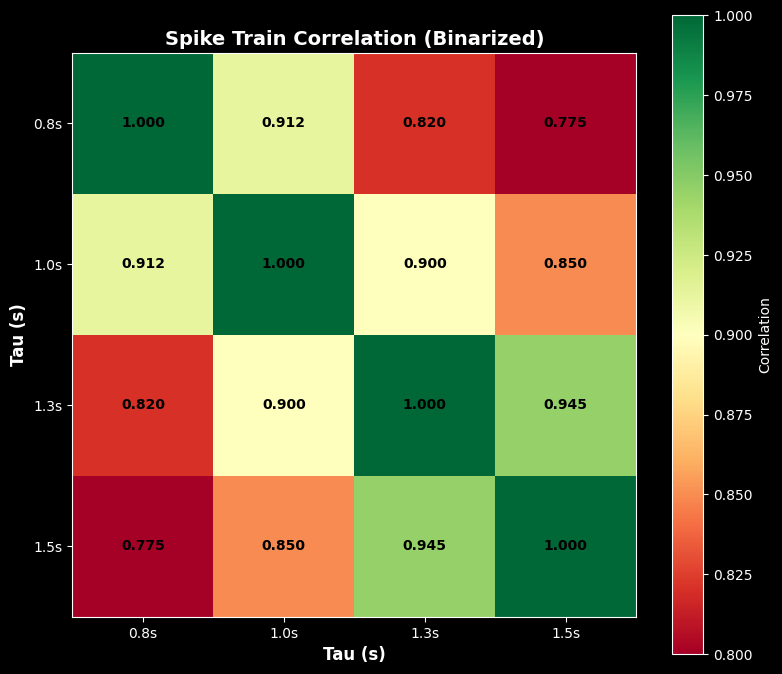


Correlation between spike trains (higher = more similar):
[[1.         0.91201173 0.82036288 0.77494932]
 [0.91201173 1.         0.89950892 0.84971386]
 [0.82036288 0.89950892 1.         0.94464186]
 [0.77494932 0.84971386 0.94464186 1.        ]]


In [13]:
# Compute correlation between spike trains (binarized)
correlation_matrix = np.zeros((len(tau_values), len(tau_values)))

for i, tau_i in enumerate(tau_values):
    for j, tau_j in enumerate(tau_values):
        spks_i = (spks_dict[tau_i] > 0).astype(float).flatten()
        spks_j = (spks_dict[tau_j] > 0).astype(float).flatten()
        correlation_matrix[i, j] = np.corrcoef(spks_i, spks_j)[0, 1]

# Plot correlation matrix
fig, ax = plt.subplots(figsize=(8, 7), facecolor='black')
im = ax.imshow(correlation_matrix, cmap='RdYlGn', vmin=0.8, vmax=1.0)

ax.set_xticks(range(len(tau_values)))
ax.set_yticks(range(len(tau_values)))
ax.set_xticklabels([f'{t}s' for t in tau_values])
ax.set_yticklabels([f'{t}s' for t in tau_values])
ax.set_xlabel('Tau (s)', fontweight='bold', fontsize=12)
ax.set_ylabel('Tau (s)', fontweight='bold', fontsize=12)
ax.set_title('Spike Train Correlation (Binarized)', fontweight='bold', fontsize=14)

# Add correlation values as text
for i in range(len(tau_values)):
    for j in range(len(tau_values)):
        text = ax.text(j, i, f'{correlation_matrix[i, j]:.3f}',
                      ha='center', va='center', color='black', fontweight='bold')

plt.colorbar(im, ax=ax, label='Correlation')
plt.tight_layout()
plt.savefig(merged_path / 'tau_spike_correlation.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()

print("\nCorrelation between spike trains (higher = more similar):")
print(correlation_matrix)

## Save recommended spks.npy with tau=1.0s

Export the spike inference using tau=1.0s (correct for jGCaMP7s)

In [ ]:
# Uncomment to save
# spks_jgcamp7s = spks_dict[1.0]
# np.save(merged_path / 'spks_tau1.0.npy', spks_jgcamp7s)
# print(f"Saved spks with tau=1.0s to {merged_path / 'spks_tau1.0.npy'}")

print("To use tau=1.0s in future runs, add to ops: {'tau': 1.0}")